# Exercícios — Redução de Dimensionalidade

**Tema:** Aprendizado Não Supervisionado › Redução de Dimensionalidade

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(525)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CORES = np.array([AZUL, VERMELHO, VERDE, ROXO, AMBAR, "#5A5A5A"])
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho: 30 sensores de uma linha de extrusão

1.500 leituras de 30 sensores. Por trás deles há três fatores físicos
(temperatura do forno, velocidade da linha, umidade do material) e a
linha opera em alguns **regimes** de produção diferentes — nenhum dos dois
é observado diretamente. Um dos sensores mede pressão em **pascal**
(valores na casa de 100 mil); os outros estão em unidades normalizadas.
A coluna `defeito` indica peça reprovada na inspeção.

In [2]:
n = 1500
medias_regime = np.array([[0, 0, 0], [4, 0, 1], [0, 4, -1], [4, 4, 3]], dtype=float)
regime = rng.integers(0, 4, n)
fatores = medias_regime[regime] + rng.normal(0, 1, (n, 3))
cargas = rng.normal(0, 1, (3, 29))
sensores = fatores @ cargas + rng.normal(0, 0.8, (n, 29))
pressao_pa = 101_325 + 2_500 * fatores[:, 1] + rng.normal(0, 400, n)
df = pd.DataFrame(sensores, columns=[f"s{j:02d}" for j in range(1, 30)])
df["pressao_pa"] = pressao_pa.round(1)
desvio_temp = fatores[:, 0] - medias_regime[regime, 0]
defeito = (rng.random(n) < 1 / (1 + np.exp(-(-2.2 + 1.6 * desvio_temp)))).astype(int)
print(df.iloc[:5, [0, 1, 2, -1]].to_string())
print(f"\n{df.shape[1]} sensores | taxa de defeito: {defeito.mean():.1%}")

        s01        s02       s03  pressao_pa
0 -1.567919  -1.707501 -1.928045    111955.3
1 -4.471529  -5.292449 -3.165965    111896.2
2 -0.264493   0.317072 -1.270957    111795.5
3  0.675680   0.403232  0.460801     97221.1
4 -7.766625 -10.077675  0.161842    100382.0

30 sensores | taxa de defeito: 18.2%


---
## Exercício 1 🟢 — PCA à mão com duas variáveis

Duas variáveis com variâncias 5 e 2 e covariância 2. Calcule, à mão, os
dois autovalores da matriz de covariância, a fração da variância
explicada pelo primeiro componente e o primeiro autovetor (normalizado).
Confira com `np.linalg.eigh`.

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
S = np.array([[5.0, 2.0], [2.0, 2.0]])
tr, det = np.trace(S), np.linalg.det(S)
lam = np.array([(tr + np.sqrt(tr ** 2 - 4 * det)) / 2, (tr - np.sqrt(tr ** 2 - 4 * det)) / 2])
print(f"traço={tr}, determinante={det:.0f} -> autovalores {lam}")
print(f"fração do 1º componente: {lam[0] / lam.sum():.3f}")
v = np.array([2.0, 1.0]) / np.sqrt(5)
print(f"autovetor à mão: {v.round(3)}  | S @ v = {S @ v.round(6)} = 6 * v? {np.allclose(S @ v, 6 * v)}")
val, vec = np.linalg.eigh(S)
print(f"np.linalg.eigh: autovalores {val[::-1]}, 1º autovetor {np.abs(vec[:, -1]).round(3)}")

traço=7.0, determinante=6 -> autovalores [6. 1.]
fração do 1º componente: 0.857
autovetor à mão: [0.894 0.447]  | S @ v = [5.366563 2.683282] = 6 * v? True
np.linalg.eigh: autovalores [6. 1.], 1º autovetor [0.894 0.447]


**Por quê:** a equação característica é $\lambda^2 - 7\lambda + 6 = 0$
(traço 7, determinante $5 \cdot 2 - 2 \cdot 2 = 6$), com raízes 6 e 1. O
primeiro componente explica $6/7 \approx 85{,}7\%$. O autovetor sai de
$(5-6)v_1 + 2v_2 = 0$, isto é, $v_1 = 2v_2$: a direção $(2, 1)$,
normalizada para $(0{,}894;\ 0{,}447)$. As duas variáveis entram com o
mesmo sinal — o padrão de variáveis positivamente correlacionadas.

---
## Exercício 2 🟢 — Quantos componentes?

Padronize os 30 sensores e ajuste um PCA. Quantos componentes são
necessários para 90% e para 95% da variância? O que diz a regra de
Kaiser? Compare com o número de fatores físicos que você sabe que existem
(3) e explique a diferença.

In [5]:
# --- sua resposta ---

### Gabarito 2

90%: 4 componentes | 95%: 8 componentes | Kaiser: 3 componentes
variância explicada pelos 6 primeiros: [0.496 0.236 0.149 0.026 0.024 0.008]


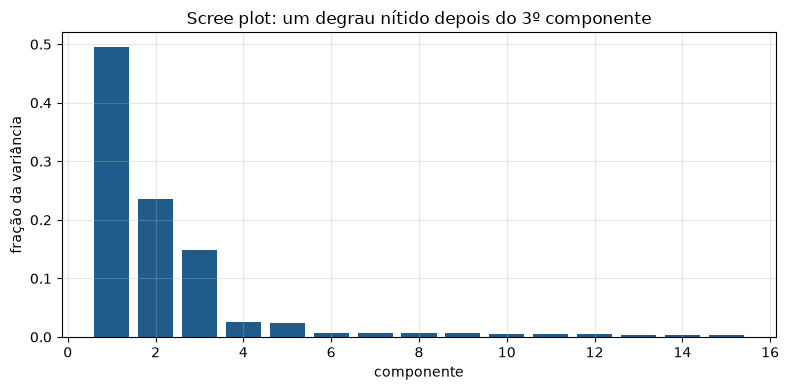

In [6]:
Z = StandardScaler().fit_transform(df)
pca = PCA().fit(Z)
acum = np.cumsum(pca.explained_variance_ratio_)
print(f"90%: {np.searchsorted(acum, 0.90) + 1} componentes | "
      f"95%: {np.searchsorted(acum, 0.95) + 1} componentes | "
      f"Kaiser: {(pca.explained_variance_ > 1).sum()} componentes")
print("variância explicada pelos 6 primeiros:", pca.explained_variance_ratio_[:6].round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 16), pca.explained_variance_ratio_[:15], color=AZUL)
ax.set_xlabel("componente"); ax.set_ylabel("fração da variância")
ax.set_title("Scree plot: um degrau nítido depois do 3º componente")
plt.tight_layout(); plt.show()

**Por quê:** o scree plot mostra um degrau nítido depois do 3º componente
— os três fatores físicos. Kaiser acerta em cheio aqui. Os limiares de
90% e 95% pedem mais componentes, porque os 5–10% restantes são o ruído
próprio de cada sensor, espalhado igualmente por todas as outras
direções: para "explicar" ruído independente é preciso muitos
componentes, cada um com um pedacinho. O cotovelo encontra a estrutura; o
limiar de variância, não necessariamente.

---
## Exercício 3 🟡 — O sensor em pascal

Ajuste um PCA nos dados **sem** padronizar. Quanto da variância o PC1
"explica"? Qual é a maior carga do PC1? Repita com os dados padronizados e
compare as cargas de `pressao_pa` nos dois casos.

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
bruto = PCA().fit(df)
cargas_bruto = pd.Series(bruto.components_[0], index=df.columns)
padron = PCA().fit(Z)
cargas_pad = pd.Series(padron.components_[0], index=df.columns)
print(f"sem padronizar: PC1 explica {bruto.explained_variance_ratio_[0]:.4%}; "
      f"maior carga em módulo: {cargas_bruto.abs().idxmax()} ({cargas_bruto.abs().max():.4f})")
print(f"padronizado   : PC1 explica {padron.explained_variance_ratio_[0]:.1%}; "
      f"carga de pressao_pa = {abs(cargas_pad['pressao_pa']):.3f} "
      f"(média das cargas em módulo: {cargas_pad.abs().mean():.3f})")

sem padronizar: PC1 explica 99.9990%; maior carga em módulo: pressao_pa (1.0000)
padronizado   : PC1 explica 49.6%; carga de pressao_pa = 0.191 (média das cargas em módulo: 0.171)


**Por quê:** a pressão em pascal tem desvio-padrão de milhares de
unidades; os outros sensores, de poucas unidades. Sem padronizar, o PC1 é
a própria pressão, com uma "variância explicada" de quase 100% que não
significa nada. Padronizada, a pressão vira mais um sensor, com carga da
mesma ordem das outras — ela carrega o fator "velocidade da linha", e
aparece junto com os demais sensores desse fator.

---
## Exercício 4 🟡 — PCA antes do modelo de defeito

Monte um `Pipeline` (padronização → PCA → regressão logística) para
prever `defeito` e escolha `n_components` entre 1, 2, 3, 5, 10 e 30 por
validação cruzada (AUC). Compare com o modelo sem PCA. Nesta base, PCA
ajuda, atrapalha ou é neutro? Por que o resultado é diferente do
experimento dos sensores de turno/lote do notebook `01-pca-aplicado`?

In [9]:
# --- sua resposta ---

### Gabarito 4

In [10]:
pipe = Pipeline([("escala", StandardScaler()), ("pca", PCA()),
                 ("modelo", LogisticRegression(max_iter=2000))])
busca = GridSearchCV(pipe, {"pca__n_components": [1, 2, 3, 5, 10, 30]}, cv=5,
                     scoring="roc_auc").fit(df, defeito)
print(pd.DataFrame(busca.cv_results_)[["param_pca__n_components", "mean_test_score"]]
      .round(4).to_string(index=False))
sem_pca = cross_val_score(Pipeline([("escala", StandardScaler()),
                                    ("modelo", LogisticRegression(max_iter=2000))]),
                          df, defeito, cv=5, scoring="roc_auc").mean()
print(f"\nsem PCA: AUC = {sem_pca:.4f}")

 param_pca__n_components  mean_test_score
                       1           0.5721
                       2           0.5859
                       3           0.6634
                       5           0.6614
                      10           0.6595
                      30           0.6508

sem PCA: AUC = 0.6508


**Por quê:** o defeito depende do desvio de **temperatura** — um dos três
fatores físicos, que são justamente as direções de maior variância. Com 3
componentes o modelo já captura tudo o que importa, e o AUC fica até um
pouco **acima** do modelo com os 30 sensores: os componentes descartados
eram ruído, e tirá-los ajuda o modelo. Compressão de 10× sem perda. No
notebook-guia, o sinal estava numa direção de variância **pequena**, e o
PCA o descartava. A lição não é "PCA é bom" nem "PCA é ruim": é que PCA
ignora o alvo, e por isso o número de componentes precisa ser validado
**no modelo**, nunca só pela variância explicada. (Note também que com 1
ou 2 componentes o AUC cai: o fator de temperatura pode não ser o 1º
nem o 2º componente.)

O AUC modesto, na casa de 0,66, tem outra causa: o defeito depende do
desvio de temperatura **em relação à média do regime**, e um modelo linear
que não sabe em que regime a linha está só enxerga a temperatura
absoluta. A célula abaixo antecipa o exercício 5: acrescentar o regime
(encontrado por clustering) como feature.

In [11]:
regime_estimado = KMeans(4, n_init=10, random_state=0).fit_predict(PCA(10).fit_transform(Z))
X_com_regime = np.column_stack([PCA(3).fit_transform(Z), np.eye(4)[regime_estimado]])
auc_regime = cross_val_score(LogisticRegression(max_iter=2000), X_com_regime, defeito,
                             cv=5, scoring="roc_auc").mean()
print(f"AUC com 3 componentes + regime estimado (one-hot): {auc_regime:.3f}")

AUC com 3 componentes + regime estimado (one-hot): 0.768


Clustering e redução de dimensionalidade trabalhando juntos: o regime
encontrado sem rótulo vira uma feature que o modelo supervisionado não
conseguia construir sozinho. (A rigor, o PCA e o k-means deveriam ser
ajustados dentro de cada fold; aqui foram ajustados na base inteira para
manter o exemplo curto — o vazamento é pequeno porque nenhum dos dois usa
o alvo, mas num projeto real eles entrariam no `Pipeline`.)

---
## Exercício 5 🔴 — "Vi dezenas de ilhas no t-SNE: são dezenas de regimes"

Um colega rodou t-SNE com perplexidade 2 nos 30 sensores padronizados,
viu muitas ilhas pequenas e concluiu que a linha tem muito mais regimes
de operação do que os engenheiros acreditam. Avalie a afirmação com um
procedimento defensável:

(a) refaça o t-SNE com perplexidades 2, 30 e 100 (após PCA com 10
componentes) e compare os desenhos;
(b) agrupe com k-means **no espaço do PCA**, não no do t-SNE, escolhendo
$k$ entre 2 e 8 pela silhueta;
(c) meça a trustworthiness de cada mapa;
(d) escreva a conclusão que você levaria para a reunião.

In [12]:
# --- sua resposta ---

### Gabarito 5

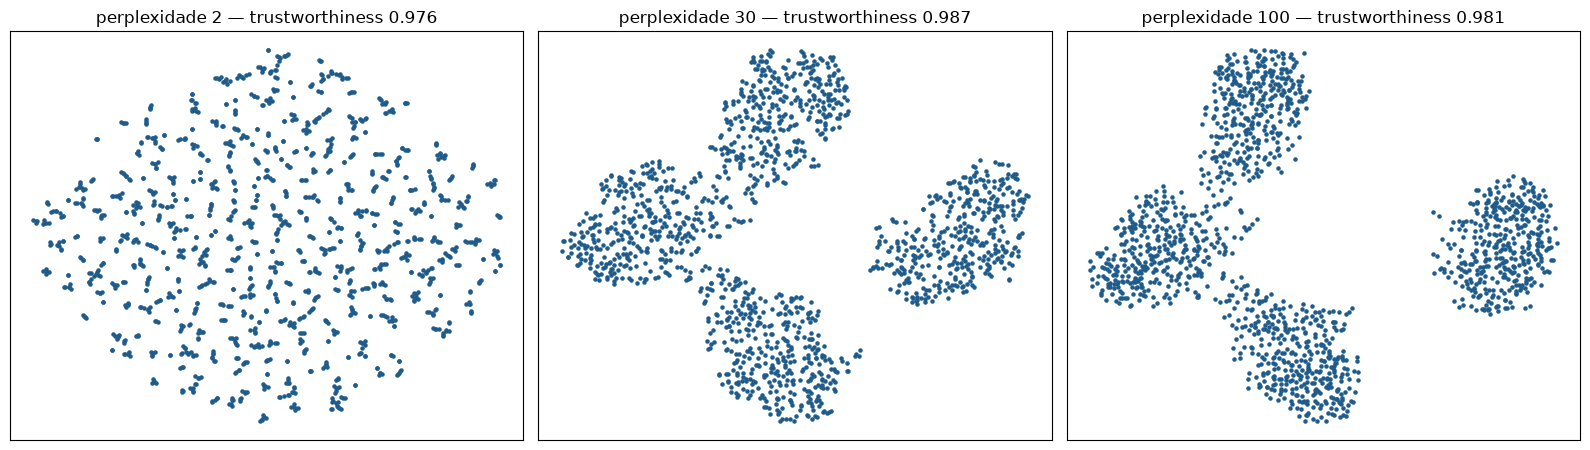

silhueta do k-means no espaço PCA(10): {2: 0.31, 3: 0.339, 4: 0.377, 5: 0.32, 6: 0.275, 7: 0.232, 8: 0.208}
melhor k = 4; ARI contra os regimes verdadeiros = 0.892


In [13]:
Z10 = PCA(10).fit_transform(Z)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, perp in zip(axes, [2, 30, 100]):
    M = TSNE(2, perplexity=perp, init="pca", random_state=0).fit_transform(Z10)
    tw = trustworthiness(Z10, M, n_neighbors=10)
    ax.scatter(M[:, 0], M[:, 1], s=5, color=AZUL)
    ax.set_title(f"perplexidade {perp} — trustworthiness {tw:.3f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

sil = {k: silhouette_score(Z10, KMeans(k, n_init=10, random_state=0).fit_predict(Z10))
       for k in range(2, 9)}
print("silhueta do k-means no espaço PCA(10):", {k: round(v, 3) for k, v in sil.items()})
k_best = max(sil, key=sil.get)
rot = KMeans(k_best, n_init=10, random_state=0).fit_predict(Z10)
print(f"melhor k = {k_best}; ARI contra os regimes verdadeiros = {adjusted_rand_score(regime, rot):.3f}")

**Conclusão para a reunião:** a estrutura robusta tem **quatro** regimes.
Com perplexidade 2, o t-SNE olha só para ~2 vizinhos e fragmenta os
regimes em muitas ilhas pequenas — o mesmo artefato do notebook-guia
(ilhas numa gaussiana única). Com perplexidades 30 e 100 aparecem quatro
grupos, e o agrupamento feito no espaço do PCA (onde as distâncias têm
significado) concorda: silhueta máxima em $k=4$, com ARI de cerca de 0,9
contra os regimes verdadeiros. As trustworthiness são altas — o que mostra que a
métrica mede preservação de **vizinhança**, não se o número de ilhas é
real. Procedimento defensável: agrupar no espaço original/PCA, usar o
t-SNE só para visualizar, e só acreditar em grupos que sobrevivem a
perplexidades e sementes diferentes.

---
## Fechamento

- Autovalores = variâncias ao longo dos componentes; o autovetor dá a
  receita da combinação linear.
- O cotovelo do scree plot encontra os fatores; limiares de 90–95%
  incluem ruído.
- Sem padronizar, uma unidade grande sequestra o PC1.
- O número de componentes de um PCA usado antes de um modelo é
  hiperparâmetro do modelo, e o sinal pode ou não estar nas direções de
  maior variância.
- Mapas t-SNE são para enxergar, não para contar grupos.

→ Próximo módulo: **Detecção de Anomalias** — encontrar o que foge do
padrão, com e sem rótulo.